In [5]:
using  LinearAlgebra, Plots;
include("IntegratorTools.jl")
include("exact_Kepler.jl")

phiKepler (generic function with 2 methods)

In [6]:
H(q,p) = sum(p.^2)/2 - 1 / norm(q);
H(z) = H(z[1:2],z[3:4]);

In [ ]:
ECC = 0.2;   z0 = [1-ECC , 0, 0,  sqrt((1+ECC)/(1-ECC))];

steps=2000; h=0.05; ts=(0:steps)*h;

uexact = phiKepler(z0, h, steps, ECC);
H_exact = mapslices(H, uexact, dims=1);

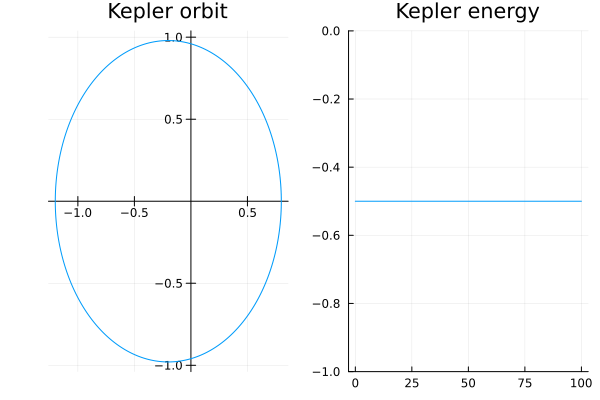

In [10]:
plot_phase=plot(uexact[1,:],uexact[2,:],frame=:origin, title="Kepler orbit",legend=false);
plot_H=plot(ts,H_exact', title="Kepler energy",legend=false,ylims=(-1,0));

plot(plot_phase,plot_H,layout=2)

In [12]:
function fKepler(y)
r=(y[1]^2+y[2]^2)^(3/2);
return Ydot = [y[3] , y[4], -y[1]/r, -y[2]/r];
end

function f1Kepler(q,p)
return Qdot = [p[1] , p[2]];
end

function f2Kepler(q,p) 
r=(q[1]^2+q[2]^2)^(3/2);
return Pdot = [-q[1]/r , -q[2]/r];
end

f2Kepler (generic function with 1 method)

In [ ]:
uE = Integrator(z -> ExpEuler(fKepler, z, 0.001), z0, 200000);
uI = Integrator(z -> ImpEuler(fKepler, z, 0.001), z0, 100000);
uS = Integrator(z -> SympEuler(f1Kepler, f2Kepler, z, 0.05), z0, 5000);
uM = Integrator(z -> MidPoint(fKepler, z, 0.05), z0, 5000);

In [ ]:
plt1=plot(title="Explicit Euler", grid=false, frame=:origin, legend=false)
plot!(plt1, uexact[1,:], uexact[2,:], lw=2);
plot!(plt1, uE[1,:], uE[2,:]);

plt2=plot(title="Implicit Euler", grid=false, frame=:origin, legend=false);
plot!(plt2, uexact[1,:], uexact[2,:], lw=2);
plot!(plt2, uI[1,:], uI[2,:]);

plt3=plot(title="Symplectic Euler", grid=false, frame=:origin, legend=false);
plot!(plt3, uexact[1,:], uexact[2,:], lw=2);
plot!(plt3, uS[1,:], uS[2,:]);

plt4=plot(title="Implicit Midpoint", grid=false, frame=:origin, legend=false);
plot!(plt4, uexact[1,:], uexact[2,:], lw=2);
plot!(plt4, uM[1,:], uM[2,:]);

plt=plot(plt1, plt2, plt3, plt4, layout=4)
#savefig(plt, "plots/sol_num_methods.pdf")

In [ ]:
include("Errors.jl")

steps=2000; h=0.05; ts=(0:steps)*h;

uE = Integrator(z -> ExpEuler(fKepler, z, h), z0, steps);
uS = Integrator(z -> SympEuler(f1Kepler, f2Kepler, z, h), z0, steps);

err_qp_expEuler, err_q_expEuler, err_H_expEuler = errors(H, z0, uE, uexact);
err_qp_symEuler, err_q_symEuler, err_H_symEuler = errors(H, z0, uS, uexact);

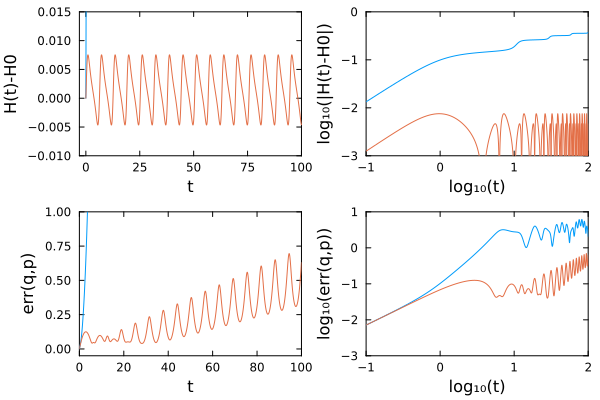

In [28]:
p1=plot(xlabel="t", ylabel="H(t)-H0",xlims=(-3,100),ylims=(-0.01, 0.015),legend=false,framestyle=:box,grid=false);
plot!(p1,ts,err_H_expEuler);
plot!(p1,ts,err_H_symEuler);


p2=plot(xlabel="log₁₀(t)", xlims=(-1,2),ylims=(-3, 0),ylabel="log₁₀(|H(t)-H0|)",legend=false,framestyle=:box,grid=false);
plot!(p2,log10.(ts[2:end]),log10.(abs.(err_H_expEuler[2:end])));
plot!(p2,log10.(ts[2:end]),log10.(abs.(err_H_symEuler[2:end])));

p3=plot(xlabel="t", ylabel="err(q,p)",xlims=(0,100),ylims=(-0.05, 1),legend=false,framestyle=:box,grid=false);
plot!(p3,ts,err_qp_expEuler');
plot!(p3,ts,err_qp_symEuler');

p4=plot(xlabel="log₁₀(t)", xlims=(-1,2),ylims=(-3, 1),ylabel="log₁₀(err(q,p))",legend=false,framestyle=:box,grid=false);
plot!(p4,log10.(ts[2:end]),log10.(err_qp_expEuler[2:end]));
plot!(p4,log10.(ts[2:end]),log10.(err_qp_symEuler[2:end]));

plot_err=plot(p1,p2,p3,p4,layout = 4)
#savefig(plot_err,"plots/errors.pdf")